In [2]:
import pandas as pd

df = pd.read_csv("/Users/bryancruz/Documents/UCSD/Datathon 1/Parking_Citations_20260404.csv", low_memory = False)

In [3]:
df.head()

,issue_date,issue_time,make,body_style,violation_description,fine_amount,loc_lat,loc_long
0,2025 Apr 26 12:00:00 AM,904,FORD,PA,DOUBLE PARKING,68,34.038267,-118.299593
1,2025 Apr 26 12:00:00 AM,830,CHEV,PA,FIRE HYDRANT,68,34.163370,-118.431059
2,2025 Apr 26 12:00:00 AM,825,TOYT,PA,METER EXP.,63,34.052868,-118.260923
3,2025 Apr 26 12:00:00 AM,935,CHEV,PU,STANDNG IN ALLEY,68,33.788801,-118.304095
4,2025 Apr 26 12:00:00 AM,"1,255",NISS,PA,EXCEED 72HRS-ST,68,34.208873,-118.592801


In [4]:
df.shape

(24307581, 8)

In [5]:
df.isnull().sum()

issue_date                    0
issue_time                 2405
make                      46807
body_style               149352
violation_description    766759
fine_amount              140010
loc_lat                       0
loc_long                      0
dtype: int64

In [6]:
df = df.dropna(subset = [
    'issue_time',
    'violation_description',
    'fine_amount',
    'loc_lat',
    'loc_long'
])

In [7]:
df.shape

(23536010, 8)

In [8]:
df['fine_amount'] = pd.to_numeric(df['fine_amount'], errors='coerce')
df['issue_time'] = df['issue_time'].astype(str).str.replace(',', '')
df['issue_time'] = pd.to_numeric(df['issue_time'], errors='coerce')
df['hour'] = df['issue_time'] // 100

In [9]:
df = df.dropna(subset=['fine_amount', 'hour'])

In [10]:
df.head()

,issue_date,issue_time,make,body_style,violation_description,fine_amount,loc_lat,loc_long,hour
0,2025 Apr 26 12:00:00 AM,904,FORD,PA,DOUBLE PARKING,68.0,34.038267,-118.299593,9
1,2025 Apr 26 12:00:00 AM,830,CHEV,PA,FIRE HYDRANT,68.0,34.163370,-118.431059,8
2,2025 Apr 26 12:00:00 AM,825,TOYT,PA,METER EXP.,63.0,34.052868,-118.260923,8
3,2025 Apr 26 12:00:00 AM,935,CHEV,PU,STANDNG IN ALLEY,68.0,33.788801,-118.304095,9
4,2025 Apr 26 12:00:00 AM,1255,NISS,PA,EXCEED 72HRS-ST,68.0,34.208873,-118.592801,12


In [11]:
df = df[
    (df['loc_lat'] > 33) & (df['loc_lat'] < 35) &
    (df['loc_long'] > -119) & (df['loc_long'] < -117)
]

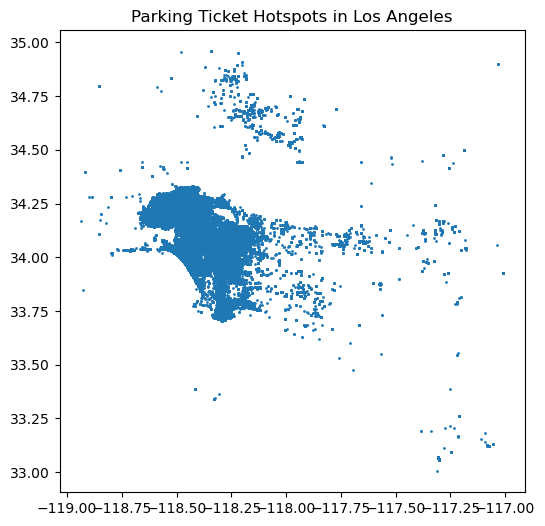

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(df['loc_long'], df['loc_lat'], s=1)
plt.title("Parking Ticket Hotspots in Los Angeles")
plt.show()

In [13]:
top_violations = df['violation_description'].value_counts().head(10)
print(top_violations)

violation_description
NO PARK/STREET CLEAN      6364126
METER EXP.                4176940
RED ZONE                  2216278
PREFERENTIAL PARKING      1760244
DISPLAY OF TABS           1112381
NO PARKING                1021152
DISPLAY OF PLATES          862454
PARKED OVER TIME LIMIT     702336
NO STOP/STANDING           450659
WHITE ZONE                 434419
Name: count, dtype: int64


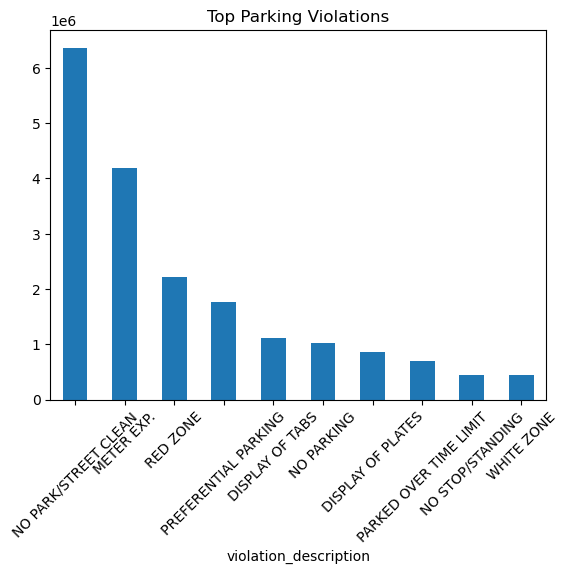

In [14]:
top_violations.plot(kind='bar')
plt.title("Top Parking Violations")
plt.xticks(rotation=45)
plt.show()

In [15]:
df.groupby('violation_description')['fine_amount'].mean().sort_values(ascending=False).head(10)

violation_description
NOSTOP/PRK-TOURBUS 3             900.0
NOSTOP/PRK-TOURBUS 2             600.0
8755**                           505.0
BLOCK DISABLED PERSON ACCESS     363.0
PK NR SDWLK RMP                  363.0
221157A                          363.0
DISABLED PARKING/BOUNDARIES      363.0
DISABLED PARKING-BLOCK ACCESS    363.0
BLOCK HANDICAP ACCESS            363.0
22522B                           363.0
Name: fine_amount, dtype: float64

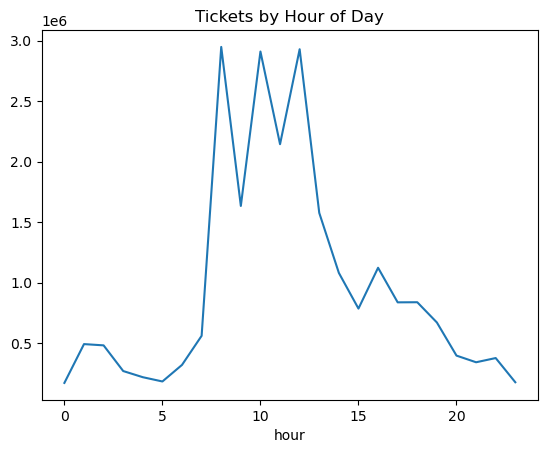

In [16]:
df['hour'].value_counts().sort_index().plot()
plt.title("Tickets by Hour of Day")
plt.show()

In [17]:
df_subset = df.sample(n = 50000, random_state = 42)
df_subset = df_subset.reset_index(drop = True)
df_subset.shape

(50000, 9)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

df_subset['high_fine'] = df_subset['fine_amount'] > df_subset['fine_amount'].median()

X = df_subset[['hour', 'loc_lat', 'loc_long']]
y = df_subset['high_fine']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)

print(f"Model Accuracy: {accuracy: .2%}")
print(f"The model correctly predicts high vs low fine tickets about {accuracy:.0%} of the time.")

Model Accuracy:  76.96%
This means the model correctly predicts high vs low fine tickets about 77% of the time.


In [20]:
print("Our model achieves around 76% accuracy in predicting whether a ticket will have a high fine based on time and location.")

Our model achieves around 76% accuracy in predicting whether a ticket will have a high fine based on time and location.
